- 데이터 병합(Table Join)

In [2]:
import pandas as pd 

In [3]:
df_product = pd.read_csv('2_store_product.csv')
df_member = pd.read_csv('1_store_member.csv')

In [4]:
df_product.head(3)

,공급일자,물품코드,물품대분류,물품중분류,물품소분류,물품명,구매수량,구매금액,구매매장,반품_원거래일자,회원번호
0,20170201,50142001,채소,잎/줄기채소,시금치,시금치(300g),1.0,2000,매장3,NaN,2101.0
1,20170201,60302012,축산물,육가공,돈가스/분쇄가공,튀김옷돈가스(400g),1.0,6300,매장3,NaN,2101.0
2,20170201,80301002,간식,밀가공,라면,감자라면(110g:1봉),2.0,2600,매장3,NaN,2101.0


In [5]:
df_member.head(3)

,회원번호,회원상태,성별,결혼유무,주소,생년,연령
0,2101,정상회원,여,기혼,서울 강북구 미아동 134-,1967,51
1,2102,정상회원,여,NaN,경기 용인시 수지구 동천동,1947,71
2,2103,정상회원,여,기혼,경기 용인시 수지구 동천동,1972,46


In [6]:
df_product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 735783 entries, 0 to 735782
Data columns (total 11 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   공급일자      735783 non-null  int64  
 1   물품코드      735783 non-null  int64  
 2   물품대분류     735783 non-null  object 
 3   물품중분류     735783 non-null  object 
 4   물품소분류     735783 non-null  object 
 5   물품명       735783 non-null  object 
 6   구매수량      735783 non-null  float64
 7   구매금액      735783 non-null  int64  
 8   구매매장      735783 non-null  object 
 9   반품_원거래일자  10337 non-null   float64
 10  회원번호      735761 non-null  float64
dtypes: float64(3), int64(3), object(5)
memory usage: 61.7+ MB


In [7]:
df_member.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4396 entries, 0 to 4395
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   회원번호    4396 non-null   int64 
 1   회원상태    4396 non-null   object
 2   성별      4396 non-null   object
 3   결혼유무    3449 non-null   object
 4   주소      4396 non-null   object
 5   생년      4396 non-null   int64 
 6   연령      4396 non-null   int64 
dtypes: int64(3), object(4)
memory usage: 240.5+ KB


 - 고객의 구매정보를 활용해, 한명의 고객에 대한 구매금액, 방문횟수, 구매수량 등을 계산하여, 고객의 인구통계적 특성과 결합해 분석해보기 

In [8]:
 # 1. 구매 데이터에서 고객의 구매금액, 방문횟수, 구매수량과 같은 통계량을 계산 
p1 = df_product.pivot_table(index='회원번호', 
                       values=['구매금액', '구매수량'], aggfunc='sum').reset_index()

# reset_index() : pivot_table 의 결과로 index로 잡혀진 데이터를 다시 index를 정렬하여 
# 데이터로 활용할 수 있게 변경해주는 함수이다. (index를 재정렬 하는 함수)

In [9]:
# 항목 명을 변경하는 방법 / .rename() : 항목 명을 변경해줌 -> 리스트 형태가 아닌 딕셔너리 구조로 입력해야함
p2 = p1.rename(columns={'구매금액':'총 구매금액', '구매수량':'총 구매수량'})
p2

,회원번호,총 구매금액,총 구매수량
0,2101.0,1991230,382.0
1,2102.0,2095860,472.5
2,2103.0,8273550,1675.4
3,2104.0,6289495,1401.8
4,2105.0,3067930,602.0
...,...,...,...
4280,6492.0,51550,10.0
4281,6493.0,22500,3.0
4282,6494.0,18500,3.0
4283,6495.0,5300,1.0


In [10]:
df_member

,회원번호,회원상태,성별,결혼유무,주소,생년,연령
0,2101,정상회원,여,기혼,서울 강북구 미아동 134-,1967,51
1,2102,정상회원,여,NaN,경기 용인시 수지구 동천동,1947,71
2,2103,정상회원,여,기혼,경기 용인시 수지구 동천동,1972,46
3,2104,정상회원,여,NaN,경기 용인시 수지구 성복동,1969,49
4,2105,정상회원,여,기혼,경기 용인시 수지구 동천동,1948,70
...,...,...,...,...,...,...,...
4391,6492,정상회원,여,미혼,경기 성남시 분당구 판교동,1963,55
4392,6493,정상회원,여,기혼,서울 관악구 행운동 1681,1982,36
4393,6494,정상회원,남,기혼,경기 성남시 분당구 백현동,1975,43
4394,6495,정상회원,여,기혼,서울 용산구 한남동 737-,1961,57


In [11]:
# 두 데이터 테이블의 병합 (pd.merge() / on = 키Column / how = 병합전략 )
m1 = pd.merge(df_member, p2, on='회원번호', how='inner')
m1.head(2)

,회원번호,회원상태,성별,결혼유무,주소,생년,연령,총 구매금액,총 구매수량
0,2101,정상회원,여,기혼,서울 강북구 미아동 134-,1967,51,1991230,382.0
1,2102,정상회원,여,NaN,경기 용인시 수지구 동천동,1947,71,2095860,472.5


In [12]:
# 한 명의 회원이 몇 번 방문했는가를 계산 : 
df_product['Label'] = 1

In [13]:
# 이런 코드를 생성해주면 회원번호 별로 공급일자가 적힌 날에 매장을 방문했는지 아닌지를 식별할 수 있음 
p3 = df_product.pivot_table(index=['회원번호','공급일자'], 
                       values='Label', aggfunc='min').reset_index()
p3

,회원번호,공급일자,Label
0,2101.0,20170102,1
1,2101.0,20170103,1
2,2101.0,20170104,1
3,2101.0,20170105,1
4,2101.0,20170106,1
...,...,...,...
96252,6492.0,20170630,1
96253,6493.0,20170630,1
96254,6494.0,20170630,1
96255,6495.0,20170630,1


In [14]:
p4 = p3.pivot_table(index='회원번호', values='Label',aggfunc='sum').reset_index()
p5 = p4.rename(columns={'Label':'총 방문횟수'})

In [15]:
p5

,회원번호,총 방문횟수
0,2101.0,86
1,2102.0,79
2,2103.0,126
3,2104.0,125
4,2105.0,57
...,...,...
4280,6492.0,1
4281,6493.0,1
4282,6494.0,1
4283,6495.0,1


In [16]:
# 방문횟수를 계산한 p5 데이터와 기존에 병합된 m1데이터를 병합
df2 = pd.merge(m1,p5, on='회원번호', how='inner')
df2.head(2)

,회원번호,회원상태,성별,결혼유무,주소,생년,연령,총 구매금액,총 구매수량,총 방문횟수
0,2101,정상회원,여,기혼,서울 강북구 미아동 134-,1967,51,1991230,382.0,86
1,2102,정상회원,여,NaN,경기 용인시 수지구 동천동,1947,71,2095860,472.5,79


In [17]:
df2

,회원번호,회원상태,성별,결혼유무,주소,생년,연령,총 구매금액,총 구매수량,총 방문횟수
0,2101,정상회원,여,기혼,서울 강북구 미아동 134-,1967,51,1991230,382.0,86
1,2102,정상회원,여,NaN,경기 용인시 수지구 동천동,1947,71,2095860,472.5,79
2,2103,정상회원,여,기혼,경기 용인시 수지구 동천동,1972,46,8273550,1675.4,126
3,2104,정상회원,여,NaN,경기 용인시 수지구 성복동,1969,49,6289495,1401.8,125
4,2105,정상회원,여,기혼,경기 용인시 수지구 동천동,1948,70,3067930,602.0,57
...,...,...,...,...,...,...,...,...,...,...
4280,6492,정상회원,여,미혼,경기 성남시 분당구 판교동,1963,55,51550,10.0,1
4281,6493,정상회원,여,기혼,서울 관악구 행운동 1681,1982,36,22500,3.0,1
4282,6494,정상회원,남,기혼,경기 성남시 분당구 백현동,1975,43,18500,3.0,1
4283,6495,정상회원,여,기혼,서울 용산구 한남동 737-,1961,57,5300,1.0,1


# Misson2.

-df2 데이터를 이용해, 아래의 문제를 해결 하고자 한다. 
1. '총구매금액'이 높은 상위 100명의 고객 명단을 추출하여, result_member_vip.xlsx로 저장

2. '성별'에 따른 '총구매금액'의 합을 비교하고자 한다. '성별' 별 ' 총구매금액'의 합을 Table로 계산하시오 

3. '총구매금액'을 '총방문횟수'로 나누어, '1회방문시구매금액'이라는 파생변수를 생성 

4. '결혼유무'에서 '기혼'에 해당하는 고객들을 추출하여, '총방문횟수'가 높은 상위 50명의 고객 명단을 뽑아, 해당 고객들의 '총구매금액'과 '총구매수량'의 평균/표준편차/중앙값을 계산하시오.

In [20]:
# 1. '총구매금액'이 높은 상위 100명의 고객 명단을 추출하여, result_member_vip.xlsx로 저장
df2.sort_values(by='총 구매금액', ascending=False).head(100).to_excel('result_member_vip.xlsx')

In [ ]:
# 2. '성별'에 따른 '총구매금액'의 합을 비교하고자 한다. '성별' 별 ' 총구매금액'의 합을 Table로 계산하시오 

In [21]:
df2.pivot_table(index='성별', values='총 구매금액', aggfunc='sum')

,총 구매금액
성별,
남,250926387
여,3925957601


In [24]:
# 3. '총구매금액'을 '총방문횟수'로 나누어, '1회방문시구매금액'이라는 파생변수를 생성 
df2['1회방문시구매금액'] = df2['총 구매금액'] / df2['총 방문횟수']
df2['1회방문시구매금액'].describe()

count      4285.000000
mean      32913.468270
std       25756.734483
min           0.000000
25%       15890.476190
50%       27166.666667
75%       43080.140845
max      329260.000000
Name: 1회방문시구매금액, dtype: float64

In [30]:
#  4. '결혼유무'에서 '기혼'에 해당하는 고객들을 추출하여, '총방문횟수'가 높은 상위 50명의 고객 명단을 뽑아, 
#  해당 고객들의 '총구매금액'과 '총구매수량'의 평균/표준편차/중앙값을 계산하시오.
cond1= (df2['결혼유무']=='기혼')
df_list1 = df2.loc[cond1].sort_values(by='총 방문횟수', ascending=False).head(50)
df_list1[['총 구매금액', '총 구매수량']].describe()

,총 구매금액,총 구매수량
count,5.000000e+01,50.000000
mean,1.015861e+07,2027.436800
std,5.090887e+06,949.747748
min,3.492665e+06,725.950000
25%,5.976940e+06,1301.800000
50%,8.805780e+06,1685.000000
75%,1.355623e+07,2819.825000
max,2.195063e+07,4425.700000


# 데이터 시각화

- matplotlib / seaborn / plotly 

In [ ]:
# 시각화 라이브러리 설치 코드 (아나콘다 X)
# !pip --trusted-host pypi.org --trusted-host files.pythonhost.org install matplotlib
# !pip --trusted-host pypi.org --trusted-host files.pythonhost.org install seaborn

In [17]:
import matplotlib as mpl          # 그래프 옵션 (글꼴)
import matplotlib.pyplot as plt   # 그래프 옵션 (그래프 축 / 범례 / 제목 / 사이즈 / ...)
import seaborn as sns             # 시각화 수행 

In [20]:
# 한글 글꼴 
mpl.rc('font', family='Malgun Gothic')

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


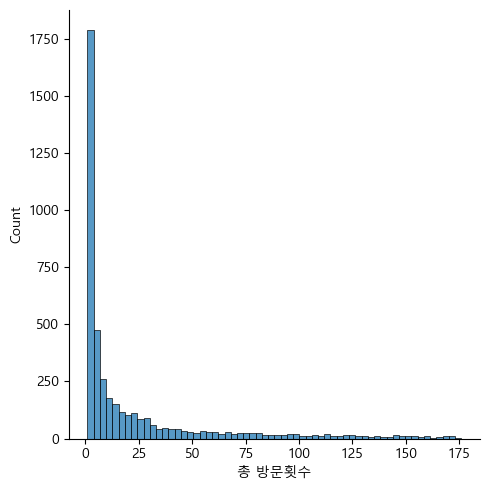

In [22]:
# 단일변수 시각화 (연속형- 히스토그램)
sns.displot(data=df2, x='총 방문횟수')
plt.savefig('image1.png') # image1.png 파일이름으로 그래프를 저장 

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


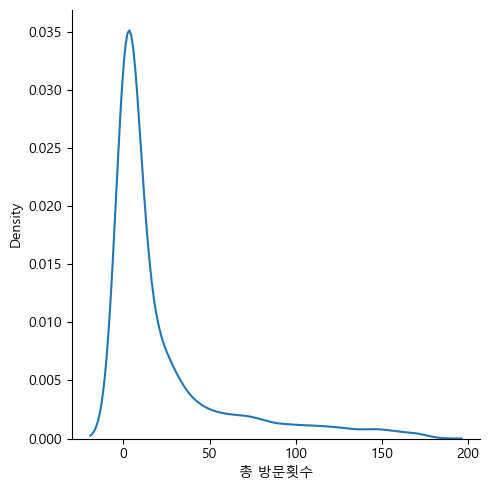

In [24]:
# 연속형 - 확률밀도함수 그래프 KDE 
sns.displot(data=df2, x='총 방문횟수', kind='kde')

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


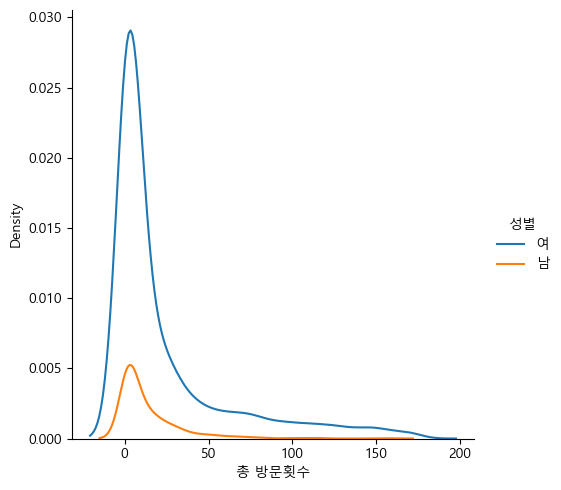

In [25]:
# 그래프 중첩 (Overlay) -> hue = ''
sns.displot(data=df2, x='총 방문횟수', kind='kde', hue='성별')

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


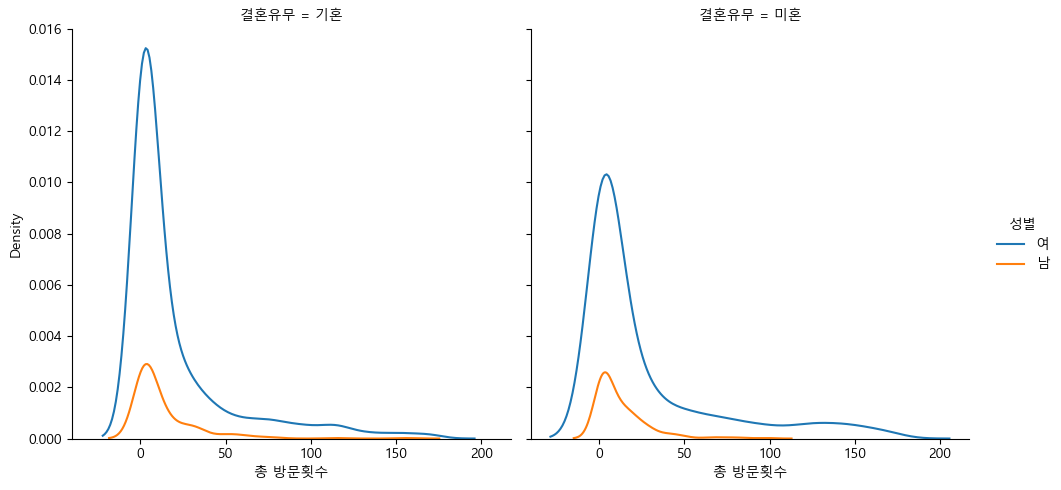

In [26]:
# 그래프 분할 (나눠서 그래프를 보는 방법 / Subplot)
sns.displot(data=df2, x='총 방문횟수', kind='kde', hue='성별', col='결혼유무')

In [ ]:
# 해당 라이브러리의 공식 홈페이지에 들어가면 다양한 그래프의 코드식을 제공해주고 있다. 